## Forecasting the stock price of the company Apple.
### Georgios Stratidis

For time series forecasting, it is common to use neural networks of the (RNN) Recurrent Neural Network category. In this project, the LSTM model is used. This model bases its prediction on the immediately previous values of the time series. These can be more than one; however, in this implementation the first previous value is used. We are specifically interested in the open price, which refers to the stock price at the beginning of each day. The dataset contains values for all days in the period 2015–2020.

### 1. Importing the data into the program.
#### 1.1 Importing the libraries.

In [1]:
import pandas as pd
import numpy as np
from pandas import DataFrame
from pandas import concat
from math import sqrt
import numpy as np
from numpy import concatenate
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.layers import LSTM

#### 1.2 Importing the dataset.

In [2]:
df = pd.read_csv('./dataset.csv')
df.head()

,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


### 2 Processing the dataset.

#### 2.1 Removing the data that we are not interested in.
We want to keep only the values of the open variable. Therefore, we remove all other columns.

In [3]:
df = df.drop(df.columns[[0,1]],axis=1)
df.drop(['splitFactor'],axis=1,inplace=True)
df.date = pd.to_datetime(df.date)
df.date = df.date.dt.date
df = df.set_index('date')
df.head()
df=df.drop(df.columns[[0,1,2,4,5,6,7,8,9,10]],axis=1)
df.head()


,open
date,
2015-05-27,130.34
2015-05-28,131.86
2015-05-29,131.23
2015-06-01,131.20
2015-06-02,129.86


#### 2.2 We check whether we have NULL values.

In [4]:
df.isnull().sum()

open    0
dtype: int64

#### 2.3 Converting the time series into supervised form.
This form is simply the addition of one more column for each variable, which refers to its previous value. Also, we scale our data.

In [5]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars=1 if type(data) is list else data.shape[1]
    df= DataFrame(data)
    cols, names =list(), list()
    
    for i in range(n_in,0,-1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
            
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]         
            
    agg=concat(cols,axis=1)
    agg.columns=names
    
    if dropnan:
        agg.dropna(inplace=True)
    return agg                 

In [6]:
values=df.values
values=values.astype('float32')
scaler = MinMaxScaler(feature_range=(0,1))
scaled = scaler.fit_transform(values)

df_new=series_to_supervised(scaled)

In [7]:
print(df_new.head())


   var1(t-1)   var1(t)
1   0.171857  0.178333
2   0.178333  0.175649
3   0.175649  0.175521
4   0.175521  0.169812
5   0.169812  0.173220


### 3 Creation of the train and test sets as well as the prediction model.


In [8]:
values=df_new.values
n_train_days= 365*2
train= values[:n_train_days,:]
test = values[n_train_days:, :]
train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]


train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1,test_X.shape[1]))


Epoch 1/50
11/11 - 5s - loss: 0.1320 - val_loss: 0.4094 - 5s/epoch - 428ms/step
Epoch 2/50
11/11 - 0s - loss: 0.0751 - val_loss: 0.2898 - 166ms/epoch - 15ms/step
Epoch 3/50
11/11 - 0s - loss: 0.0761 - val_loss: 0.2310 - 150ms/epoch - 14ms/step
Epoch 4/50
11/11 - 0s - loss: 0.0745 - val_loss: 0.1902 - 139ms/epoch - 13ms/step
Epoch 5/50
11/11 - 0s - loss: 0.0673 - val_loss: 0.1526 - 137ms/epoch - 12ms/step
Epoch 6/50
11/11 - 0s - loss: 0.0560 - val_loss: 0.1075 - 148ms/epoch - 13ms/step
Epoch 7/50
11/11 - 0s - loss: 0.0414 - val_loss: 0.0462 - 155ms/epoch - 14ms/step
Epoch 8/50
11/11 - 0s - loss: 0.0244 - val_loss: 0.0258 - 187ms/epoch - 17ms/step
Epoch 9/50
11/11 - 0s - loss: 0.0099 - val_loss: 0.0415 - 178ms/epoch - 16ms/step
Epoch 10/50
11/11 - 0s - loss: 0.0266 - val_loss: 0.0341 - 165ms/epoch - 15ms/step
Epoch 11/50
11/11 - 0s - loss: 0.0156 - val_loss: 0.0159 - 154ms/epoch - 14ms/step
Epoch 12/50
11/11 - 0s - loss: 0.0308 - val_loss: 0.0274 - 157ms/epoch - 14ms/step
Epoch 13/50
11/

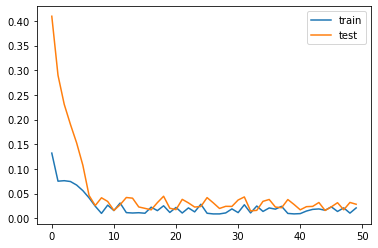

In [9]:
model= Sequential()
model.add(LSTM(200,return_sequences=True, input_shape=(train_X.shape[1],train_X.shape[2])))
model.add(LSTM(units=200))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss='mae',optimizer='adam')

history=model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X,test_y), verbose=2, shuffle=False)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

### 4 Prediction based on the immediately previous value of the time series.

In [10]:
yhat = model.predict(test_X)
test_X = test_X.reshape((test_X.shape[0], test_X.shape[2]))

inv_yhat = concatenate((yhat, test_X[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]


test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, test_X[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]

rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(inv_y,inv_yhat)
print('Test MAE: %.3f' % mae)

17/17 [==============================] - 1s 2ms/step
Test RMSE: 9.783
Test MAE: 6.667


### 5 Analysis of the results of the implementation.

In [11]:
result_comp = pd.DataFrame(list(zip(inv_y, inv_yhat)),
               columns =['Open_Price_Real', 'Open_Price_Forecast'])
result_comp.head()

,Open_Price_Real,Open_Price_Forecast
0,170.595001,176.155731
1,166.834793,171.566528
2,165.669998,167.623871
3,162.619995,166.406311
4,164.119995,163.226517


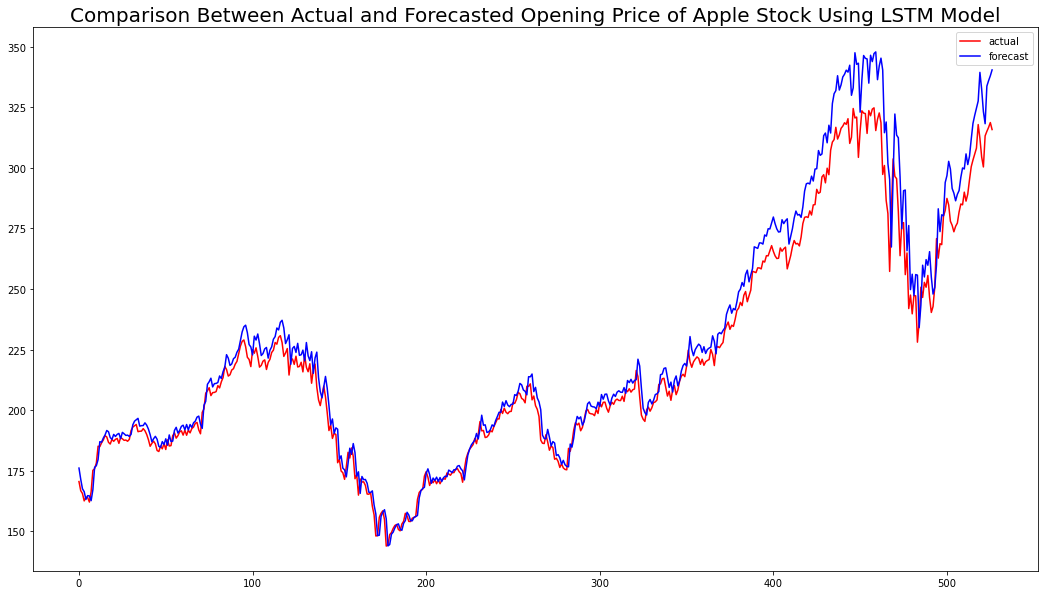

In [12]:
plt.figure(figsize=(18,10))
plt.plot(result_comp['Open_Price_Real'],label='actual',color='red')
plt.plot(result_comp['Open_Price_Forecast'],label='forecast',color='blue')
plt.title('Comparison Between Actual and Forecasted Opening Price of Apple Stock Using LSTM Model',fontsize=20)
plt.legend()